In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# images are inside question/a1images/
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

In [2]:
# same idea as q3 histeq but only touches pixels where mask is True
# CDF is built from masked pixels only, background stays unchanged
def histeq_masked(img, mask):
    pixels  = img[mask]
    hist    = np.bincount(pixels.ravel(), minlength=256).astype(np.float64)
    cdf     = hist.cumsum()
    cdf_min = cdf[cdf > 0][0]
    lut     = np.round((cdf - cdf_min) / (pixels.size - cdf_min) * 255).astype(np.uint8)
    out     = img.copy()
    out[mask] = lut[img[mask]]  # only write back to masked region
    return out

In [3]:
# load image and convert to gray
# Otsu picks the threshold automatically by maximizing between-class variance
# THRESH_BINARY_INV flips it so the darker foreground ends up white in binary
img  = cv2.imread(os.path.join(IMG_DIR, 'highlights_and_shadows.jpg'))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

thresh, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f'Otsu threshold: {int(thresh)}')

Otsu threshold: 91


In [4]:
# white pixels in binary are the foreground — equalize only those
mask   = binary == 255
result = histeq_masked(gray, mask)

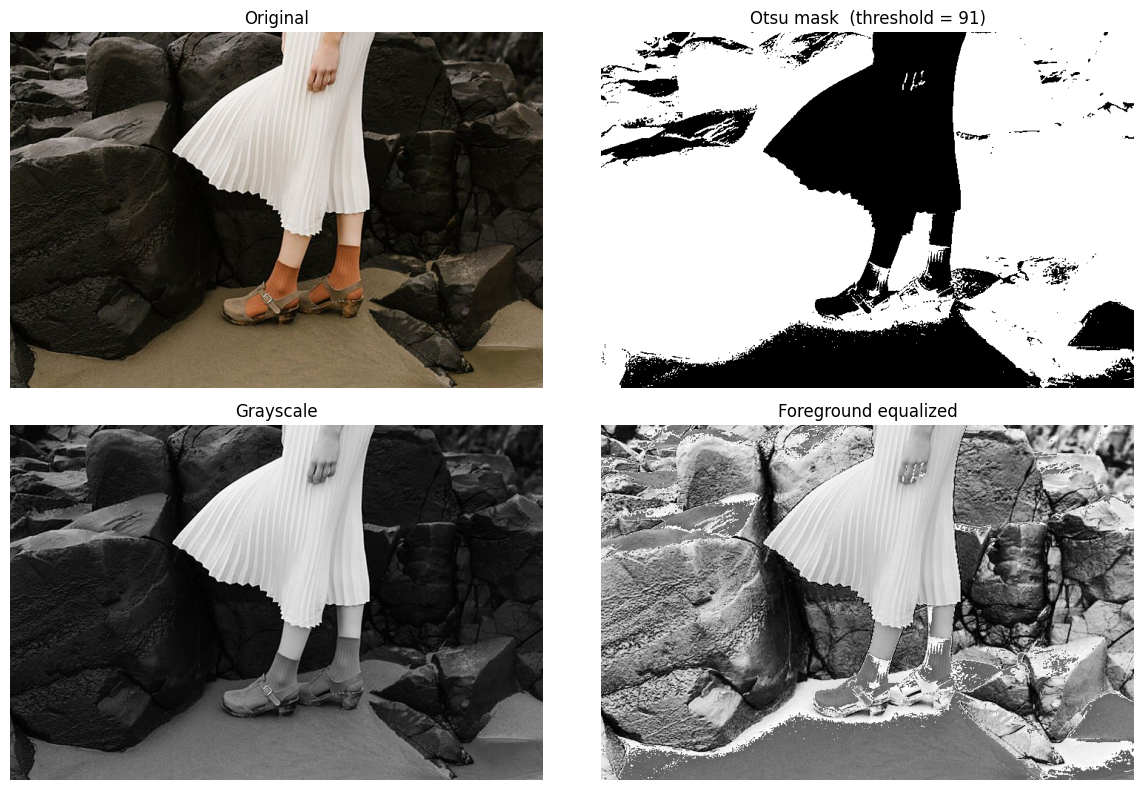

In [5]:
# top row: original color + the Otsu mask
# bottom row: plain grayscale vs the selectively equalized result
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary, cmap='gray')
axes[0, 1].set_title(f'Otsu mask  (threshold = {int(thresh)})')
axes[0, 1].axis('off')

axes[1, 0].imshow(gray, cmap='gray')
axes[1, 0].set_title('Grayscale')
axes[1, 0].axis('off')

axes[1, 1].imshow(result, cmap='gray')
axes[1, 1].set_title('Foreground equalized')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q4_otsu_eq.png'), dpi=150)
plt.show()